In [ ]:
!pip install torch torchvision timm transformers pillow opencv-python scikit-learn -q
import os
import glob
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="pCdHjiewdPWUH8idtZp7")
project = rf.workspace("imit-h5ows").project("soil-detection-l0ngo")
version = project.version(3)
dataset = version.download("yolov8")

dataset_path = dataset.location
print("Dataset downloaded to:", dataset_path)

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/Soil-detection-3


In [ ]:
import yaml

yaml_path = f"{dataset_path}/data.yaml"

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']


In [ ]:
clf_path = "/content/soil_classification_vit"
os.makedirs(clf_path, exist_ok=True)

for split in ["train", "valid"]:
    for cls in class_names:
        os.makedirs(f"{clf_path}/{split}/{cls}", exist_ok=True)

def convert_to_classification(split):
    img_dir = f"{dataset_path}/{split}/images"
    lbl_dir = f"{dataset_path}/{split}/labels"

    for img_path in glob.glob(f"{img_dir}/*.jpg"):
        img_name = os.path.basename(img_path)
        lbl_path = f"{lbl_dir}/{img_name.replace('.jpg','.txt')}"

        if not os.path.exists(lbl_path):
            continue

        with open(lbl_path, "r") as f:
            first = f.readline().strip()
            if first == "":
                continue

        cls_id = int(first.split()[0])
        cls_name = class_names[cls_id]

        out_path = f"{clf_path}/{split}/{cls_name}/{img_name}"
        img = cv2.imread(img_path)
        cv2.imwrite(out_path, img)

convert_to_classification("train")
convert_to_classification("valid")

print("Classification dataset ready at:", clf_path)

Classification dataset ready at: /content/soil_classification_vit


In [ ]:
IMG_SIZE = 224
BATCH = 16

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

valid_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

class SoilDataset(Dataset):
    def __init__(self, folder, transform):
        self.paths = []
        self.labels = []
        self.transform = transform

        for idx, cls in enumerate(class_names):
            for img in glob.glob(folder + "/" + cls + "/*.jpg"):
                self.paths.append(img)
                self.labels.append(idx)

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        img = self.transform(img)
        label = self.labels[i]
        return img, label

train_ds = SoilDataset(f"{clf_path}/train", train_tf)
valid_ds = SoilDataset(f"{clf_path}/valid", valid_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH, shuffle=False)

In [ ]:
from timm import create_model

device = "cuda" if torch.cuda.is_available() else "cpu"

model = create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = torch.tensor(labels).to(device)

        optimizer.zero_grad()

        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        correct += (preds.argmax(1) == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{EPOCHS} - Train Accuracy: {acc:.2f}%")

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Epoch 1/15 - Train Accuracy: 39.20%
Epoch 2/15 - Train Accuracy: 81.91%
Epoch 3/15 - Train Accuracy: 87.94%
Epoch 4/15 - Train Accuracy: 96.48%
Epoch 5/15 - Train Accuracy: 96.98%
Epoch 6/15 - Train Accuracy: 97.99%
Epoch 7/15 - Train Accuracy: 97.99%
Epoch 8/15 - Train Accuracy: 98.99%
Epoch 9/15 - Train Accuracy: 97.99%
Epoch 10/15 - Train Accuracy: 97.49%
Epoch 11/15 - Train Accuracy: 99.50%
Epoch 12/15 - Train Accuracy: 99.50%
Epoch 13/15 - Train Accuracy: 98.49%
Epoch 14/15 - Train Accuracy: 98.49%
Epoch 15/15 - Train Accuracy: 100.00%


In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in valid_loader:
        imgs = imgs.to(device)
        labels = torch.tensor(labels).to(device)

        preds = model(imgs)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.argmax(1).cpu().numpy())

acc = accuracy_score(y_true, y_pred) * 100
print("Final Validation Accuracy:", acc, "%")

To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Final Validation Accuracy: 77.58620689655173 %


Confusion Matrix:
 [[18  0  0  0]
 [ 3 14  0  0]
 [ 5  1  2  1]
 [ 2  0  1 11]]


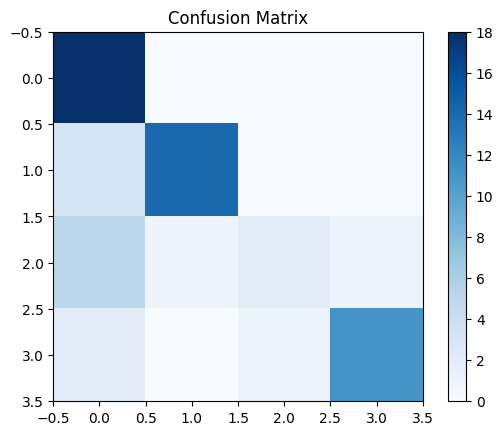

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

def predict_image(path):
    img = Image.open(path).convert("RGB")
    img = valid_tf(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img).argmax(1).item()

    return class_names[pred]

for fn in uploaded.keys():
    result = predict_image(fn)
    print(fn, "→", result)

Saving red.avif to red.avif


NameError: name 'Image' is not defined

In [ ]:
import torch

# Move model to CPU before saving (important for Render)
model_cpu = model.to("cpu")

# Save only the trained weights
torch.save(model_cpu.state_dict(), "soil_vit_weights.pth")




In [ ]:
from google.colab import files
files.download("soil_vit_weights.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>